# About the Project
The Sample Superstore Sales Analysis project focuses on analyzing sales, profit, quantity, discount, customer segments, product categories, regions, states, cities, and shipping modes using Python, Pandas, Matplotlib, and Seaborn. The dataset was cleaned by checking missing values and removing duplicate records before performing exploratory data analysis. The analysis calculates important business KPIs such as total sales, total profit, total quantity, average sales, average profit, average discount, and overall profit margin. Various visualizations were created to understand category and sub-category performance, regional and segment-wise sales, shipping performance, top-performing states and cities, quantity distribution, discount patterns, and profitability. Scatter plots were also used to study relationships between Sales and Profit and between Discount and Profit, while histograms and heatmaps helped understand data distributions and profitability patterns. The project also includes a Monthly Sales Trend analysis; however, the current dataset does not contain an Order Date or Sales Date column, so a genuine monthly trend cannot be calculated from this particular file. Overall, the project demonstrates practical skills in data cleaning, exploratory data analysis, business KPI analysis, data visualization, and extracting actionable insights from sales data.

In [1]:
# ============================================================
# SAMPLE SUPERSTORE - COMPLETE SALES ANALYSIS
# ============================================================

# Install if required:
# pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

file_path = "SampleSuperstore(1).csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Loaded Successfully
Shape: (9994, 13)

Columns:
['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


In [2]:
# ------------------------------------------------------------
# 2. BASIC DATA CLEANING
# ------------------------------------------------------------

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Records:", df.duplicated().sum())

# Remove duplicate records
df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)


Missing Values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate Records: 17

Shape after removing duplicates: (9977, 13)


In [4]:
# ------------------------------------------------------------
# 3. BASIC DATA INFORMATION
# ------------------------------------------------------------

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())



Data Types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Statistical Summary:
        Postal Code         Sales     Quantity     Discount      Profit
count   9977.000000   9977.000000  9977.000000  9977.000000  9977.00000
mean   55154.964117    230.148902     3.790719     0.156278    28.69013
std    32058.266816    623.721409     2.226657     0.206455   234.45784
min     1040.000000      0.444000     1.000000     0.000000 -6599.97800
25%    23223.000000     17.300000     2.000000     0.000000     1.72620
50%    55901.000000     54.816000     3.000000     0.200000     8.67100
75%    90008.000000    209.970000     5.000000     0.200000    29.37200
max    99301.000000  22638.480000    14.000000     0.800000  83

In [3]:
# ------------------------------------------------------------
# 4. KEY PERFORMANCE INDICATORS
# ------------------------------------------------------------

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()

average_sales = df["Sales"].mean()
average_profit = df["Profit"].mean()
average_discount = df["Discount"].mean()

profit_margin = (total_profit / total_sales) * 100

print("\n================ KPI ANALYSIS ================")

print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Total Profit     : ${total_profit:,.2f}")
print(f"Total Quantity   : {total_quantity:,}")
print(f"Average Sales    : ${average_sales:,.2f}")
print(f"Average Profit   : ${average_profit:,.2f}")
print(f"Average Discount : {average_discount:.2%}")
print(f"Profit Margin    : {profit_margin:.2f}%")



================ KPI ANALYSIS ================
Total Sales      : $2,296,195.59
Total Profit     : $286,241.42
Total Quantity   : 37,820
Average Sales    : $230.15
Average Profit   : $28.69
Average Discount : 15.63%
Profit Margin    : 12.47%



Sales by Category:
Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


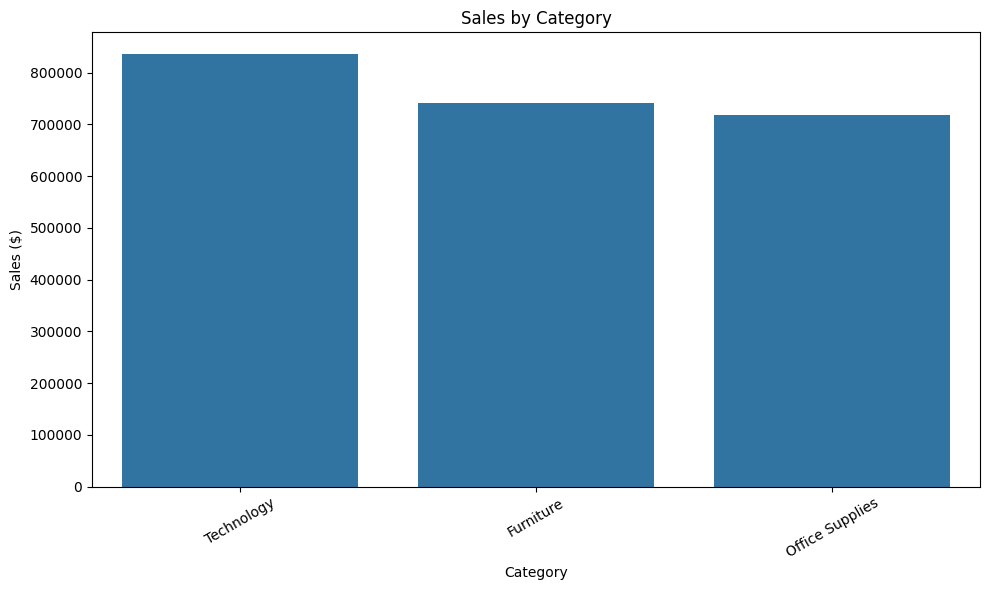

In [4]:
# ------------------------------------------------------------
# 5. SALES BY CATEGORY
# ------------------------------------------------------------

category_sales = df.groupby("Category")["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Category:")
print(category_sales)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Profit by Category:
Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64


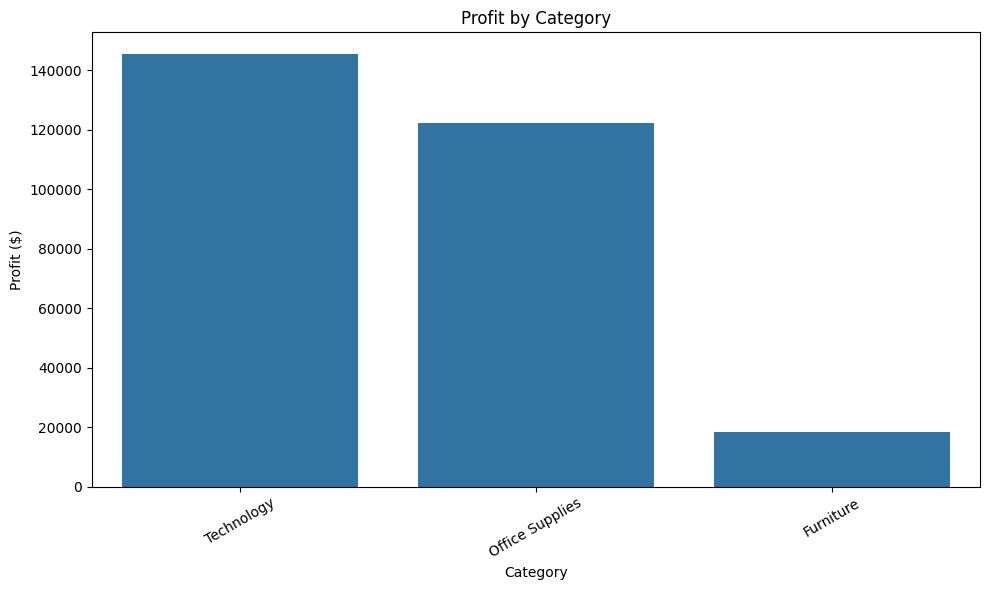

In [5]:
# ------------------------------------------------------------
# 6. PROFIT BY CATEGORY
# ------------------------------------------------------------

category_profit = df.groupby("Category")["Profit"].sum().sort_values(
    ascending=False
)

print("\nProfit by Category:")
print(category_profit)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Sales by Sub-Category:
Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91683.0240
Paper           78224.1420
Supplies        46673.5380
Art             27107.0320
Envelopes       16476.4020
Labels          12444.9120
Fasteners        3024.2800
Name: Sales, dtype: float64


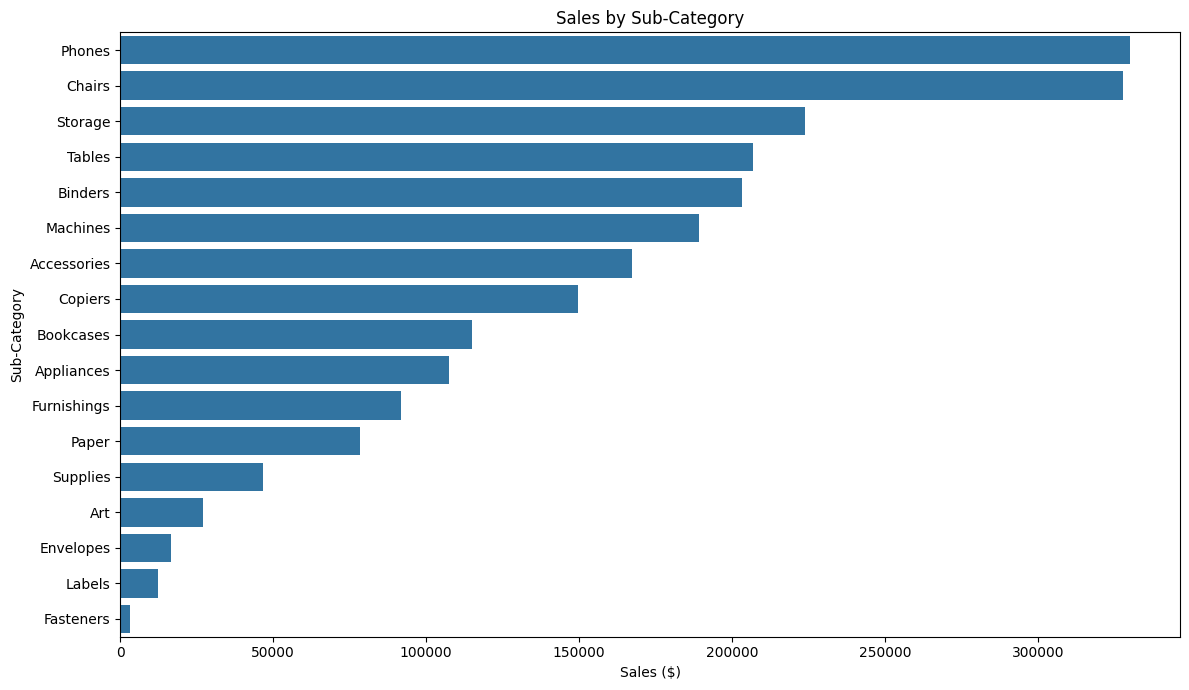

In [6]:
# ------------------------------------------------------------
# 7. SALES BY SUB-CATEGORY
# ------------------------------------------------------------

subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Sub-Category:")
print(subcategory_sales)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=subcategory_sales.values,
    y=subcategory_sales.index
)

plt.title("Sales by Sub-Category")
plt.xlabel("Sales ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


Profit by Sub-Category:
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          33944.2395
Binders        30228.0003
Chairs         26567.1278
Storage        21278.8264
Appliances     18138.0054
Furnishings    13052.7230
Envelopes       6964.1767
Art             6524.6118
Labels          5526.3820
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


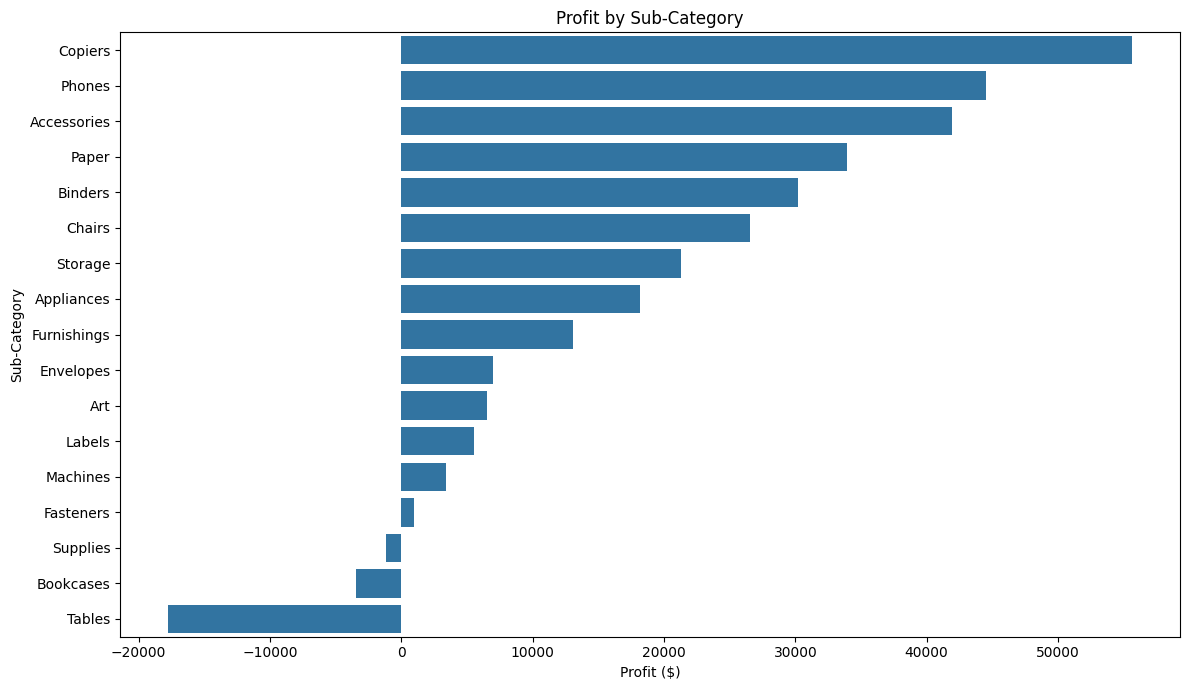

In [7]:
# ------------------------------------------------------------
# 8. PROFIT BY SUB-CATEGORY
# ------------------------------------------------------------

subcategory_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(
    ascending=False
)

print("\nProfit by Sub-Category:")
print(subcategory_profit)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=subcategory_profit.values,
    y=subcategory_profit.index
)

plt.title("Profit by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()


Sales by Region:
Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64


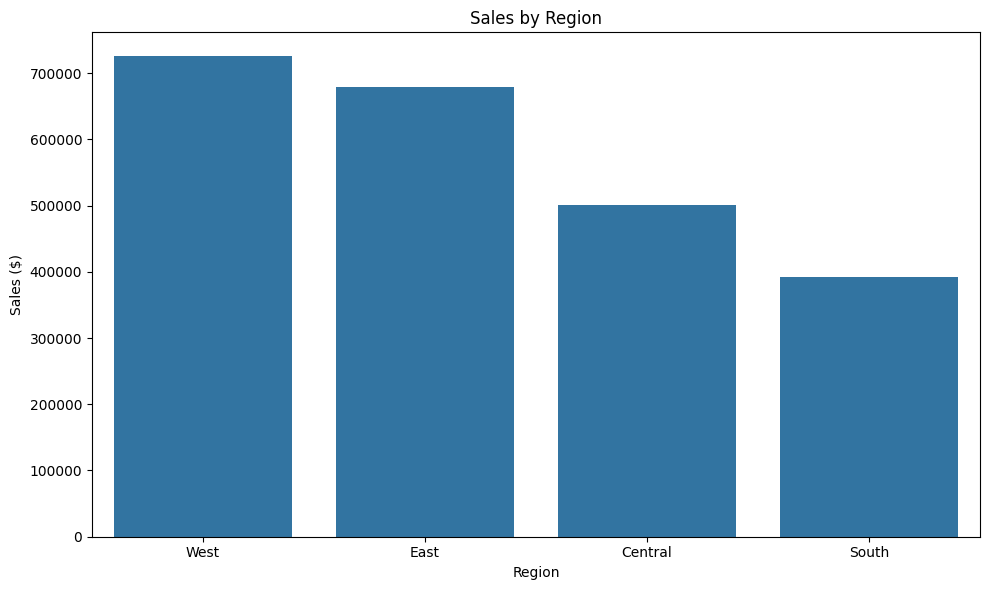

In [8]:
# ------------------------------------------------------------
# 9. REGION SALES
# ------------------------------------------------------------

region_sales = df.groupby("Region")["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Region:")
print(region_sales)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()


Profit by Region:
Region
West       108329.8079
East        91506.3092
South       46749.4303
Central     39655.8752
Name: Profit, dtype: float64


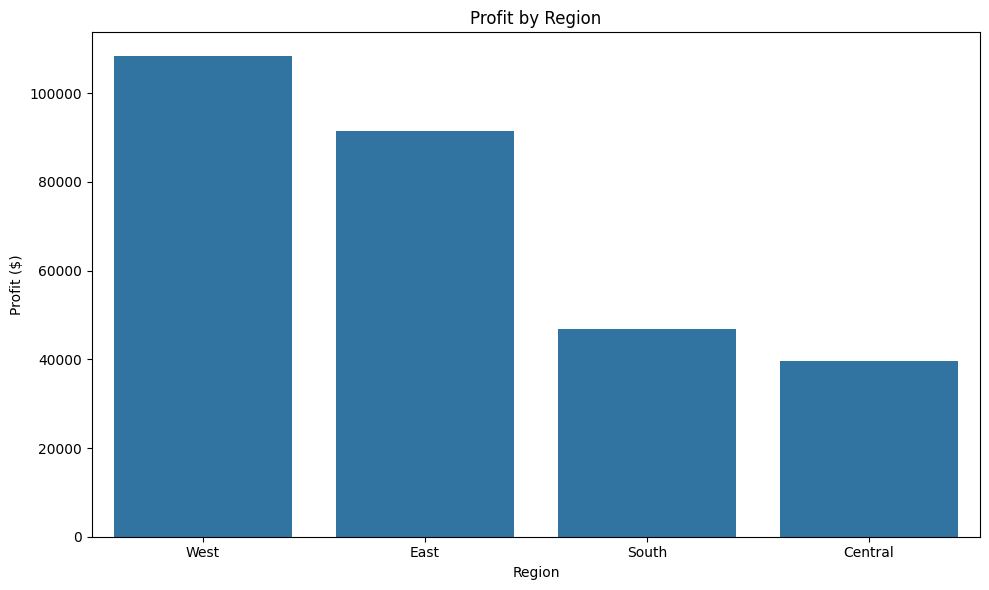

In [9]:
# ------------------------------------------------------------
# 10. REGION PROFIT
# ------------------------------------------------------------

region_profit = df.groupby("Region")["Profit"].sum().sort_values(
    ascending=False
)

print("\nProfit by Region:")
print(region_profit)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_profit.index,
    y=region_profit.values
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()


Sales by Segment:
Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64


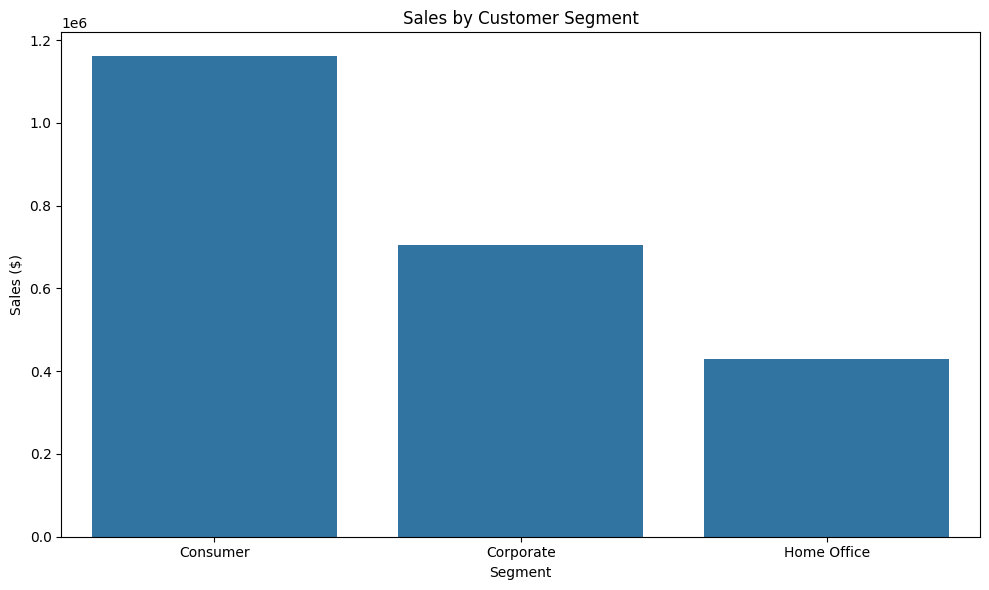

In [10]:
# ------------------------------------------------------------
# 11. SEGMENT SALES
# ------------------------------------------------------------

segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Segment:")
print(segment_sales)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()


Profit by Segment:
Segment
Consumer       134007.4413
Corporate       91954.9798
Home Office     60279.0015
Name: Profit, dtype: float64


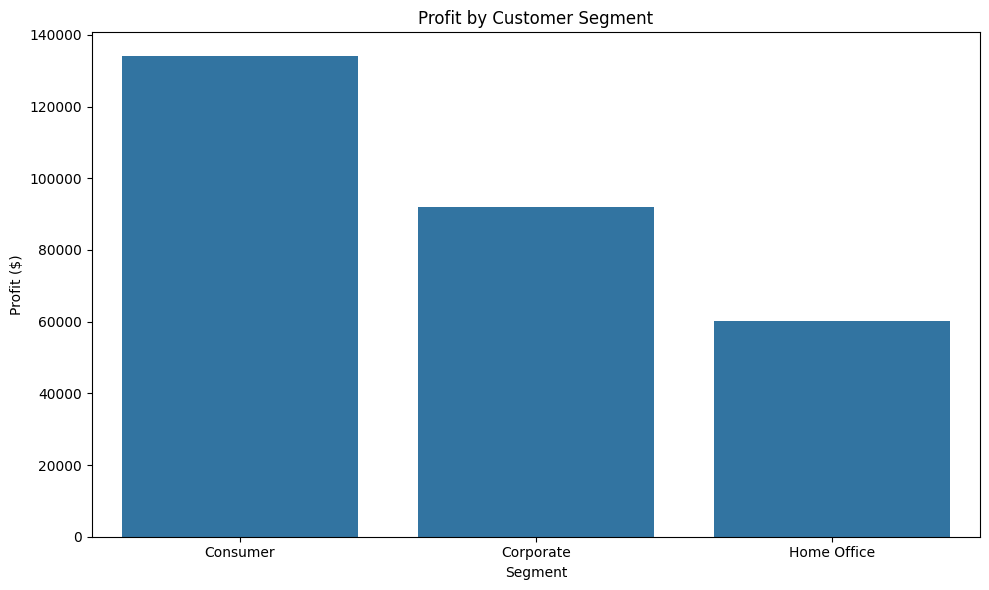

In [11]:
# ------------------------------------------------------------
# 12. SEGMENT PROFIT
# ------------------------------------------------------------

segment_profit = df.groupby("Segment")["Profit"].sum().sort_values(
    ascending=False
)

print("\nProfit by Segment:")
print(segment_profit)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_profit.index,
    y=segment_profit.values
)

plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()


Sales by Ship Mode:
Ship Mode
Standard Class    1.357316e+06
Second Class      4.591770e+05
First Class       3.513805e+05
Same Day          1.283217e+05
Name: Sales, dtype: float64


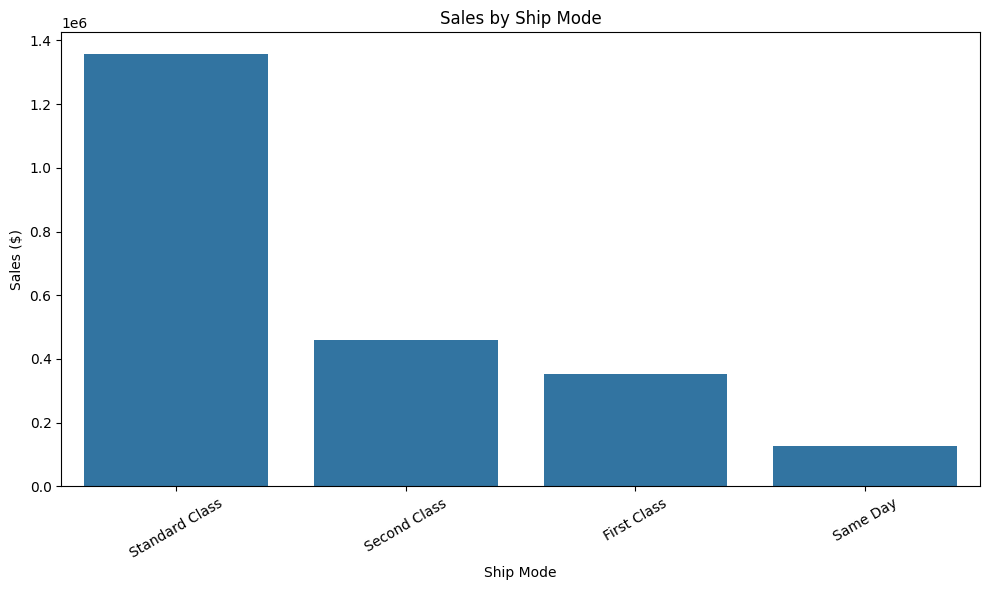

In [12]:
# ------------------------------------------------------------
# 13. SALES BY SHIP MODE
# ------------------------------------------------------------

ship_sales = df.groupby("Ship Mode")["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Ship Mode:")
print(ship_sales)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=ship_sales.index,
    y=ship_sales.values
)

plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

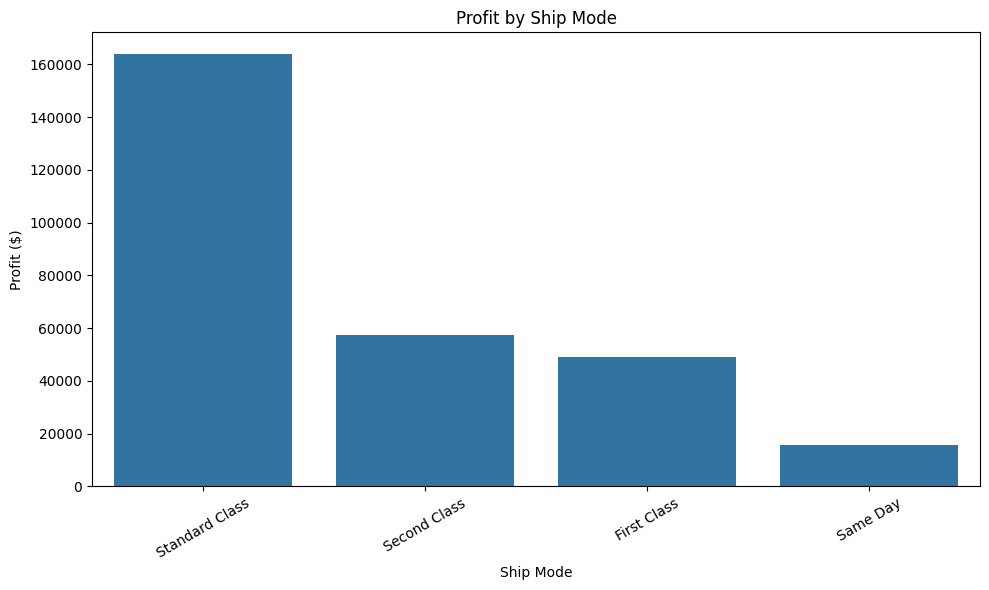

In [13]:
# ------------------------------------------------------------
# 14. PROFIT BY SHIP MODE
# ------------------------------------------------------------

ship_profit = df.groupby("Ship Mode")["Profit"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=ship_profit.index,
    y=ship_profit.values
)

plt.title("Profit by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Profit ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Top 10 States by Sales:
State
California      457576.2715
New York        310827.1510
Texas           170124.5418
Washington      138560.8100
Pennsylvania    116496.3620
Florida          89473.7080
Illinois         80162.5370
Ohio             77976.7640
Michigan         75879.6440
Virginia         70636.7200
Name: Sales, dtype: float64


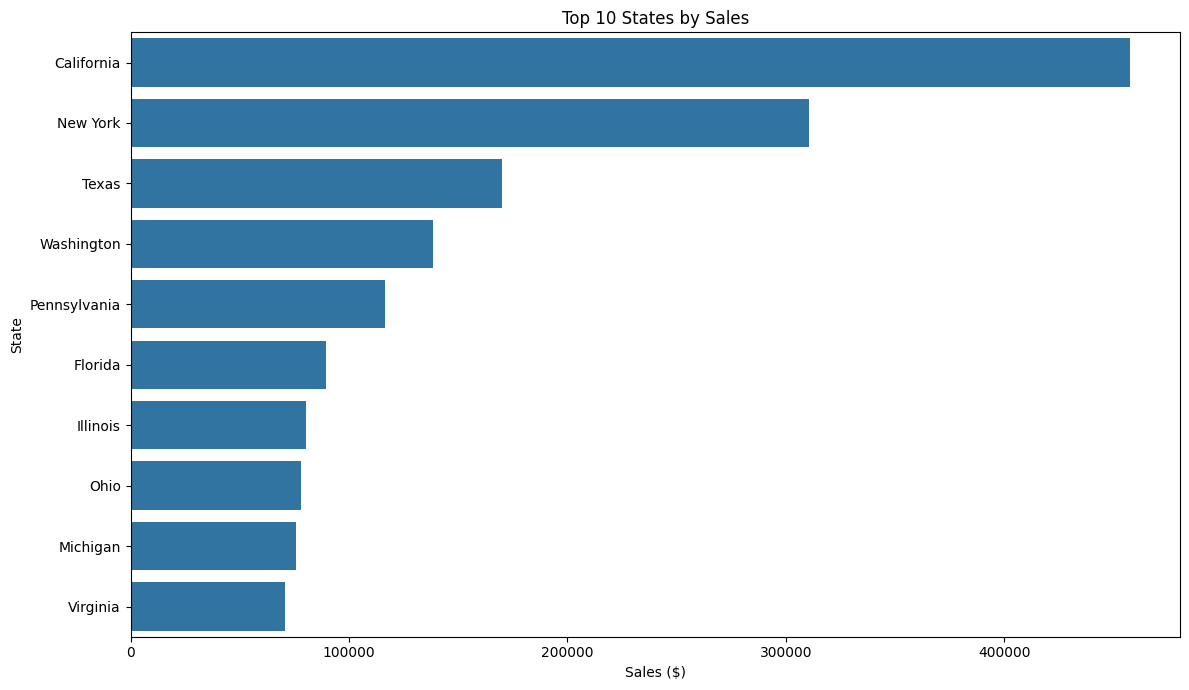

In [14]:
# ------------------------------------------------------------
# 15. TOP 10 STATES BY SALES
# ------------------------------------------------------------

state_sales = df.groupby("State")["Sales"].sum().sort_values(
    ascending=False
).head(10)

print("\nTop 10 States by Sales:")
print(state_sales)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=state_sales.values,
    y=state_sales.index
)

plt.title("Top 10 States by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

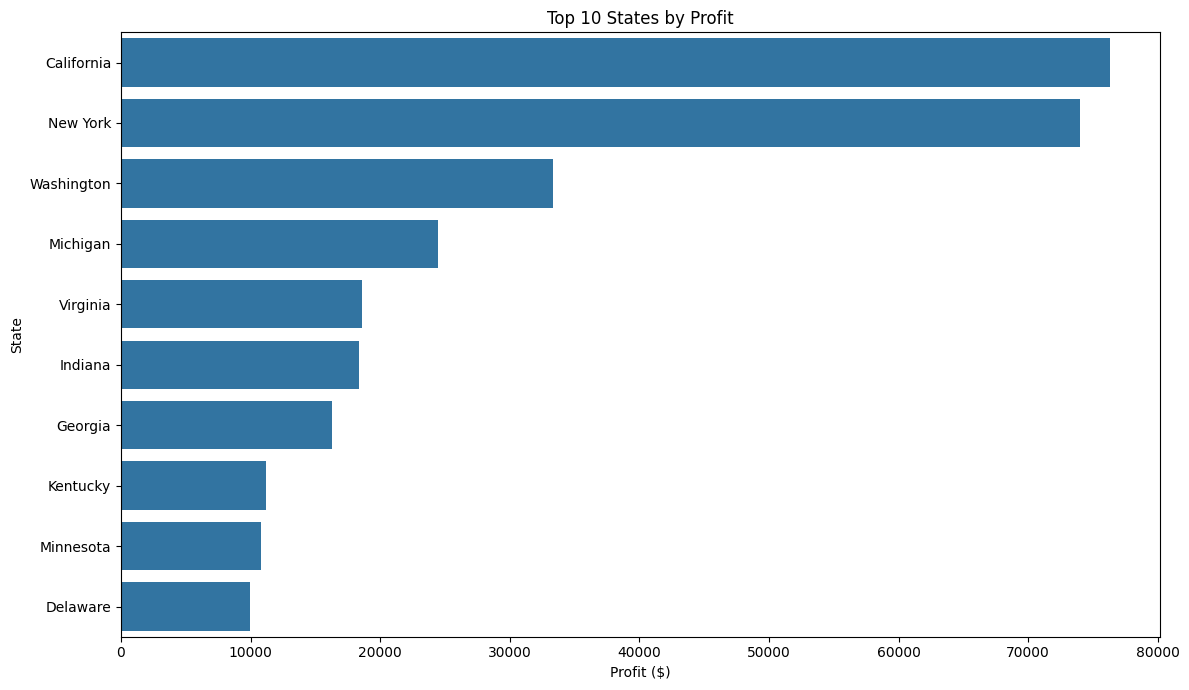

In [15]:
# ------------------------------------------------------------
# 16. TOP 10 STATES BY PROFIT
# ------------------------------------------------------------

state_profit = df.groupby("State")["Profit"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=state_profit.values,
    y=state_profit.index
)

plt.title("Top 10 States by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


Top 10 Cities by Sales:
City
New York City    256319.0410
Los Angeles      175831.9010
Seattle          119460.2820
San Francisco    112577.1720
Philadelphia     109061.4610
Houston           64441.2564
Chicago           48535.9770
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


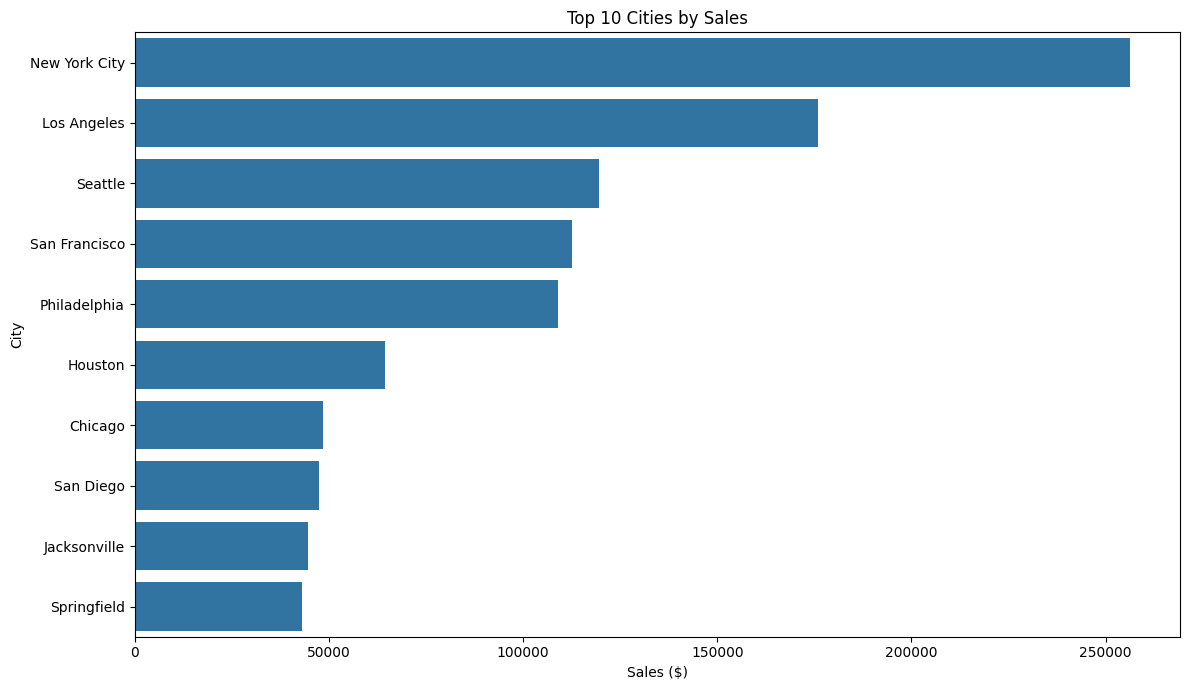

In [16]:
# ------------------------------------------------------------
# 17. TOP 10 CITIES BY SALES
# ------------------------------------------------------------

city_sales = df.groupby("City")["Sales"].sum().sort_values(
    ascending=False
).head(10)

print("\nTop 10 Cities by Sales:")
print(city_sales)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

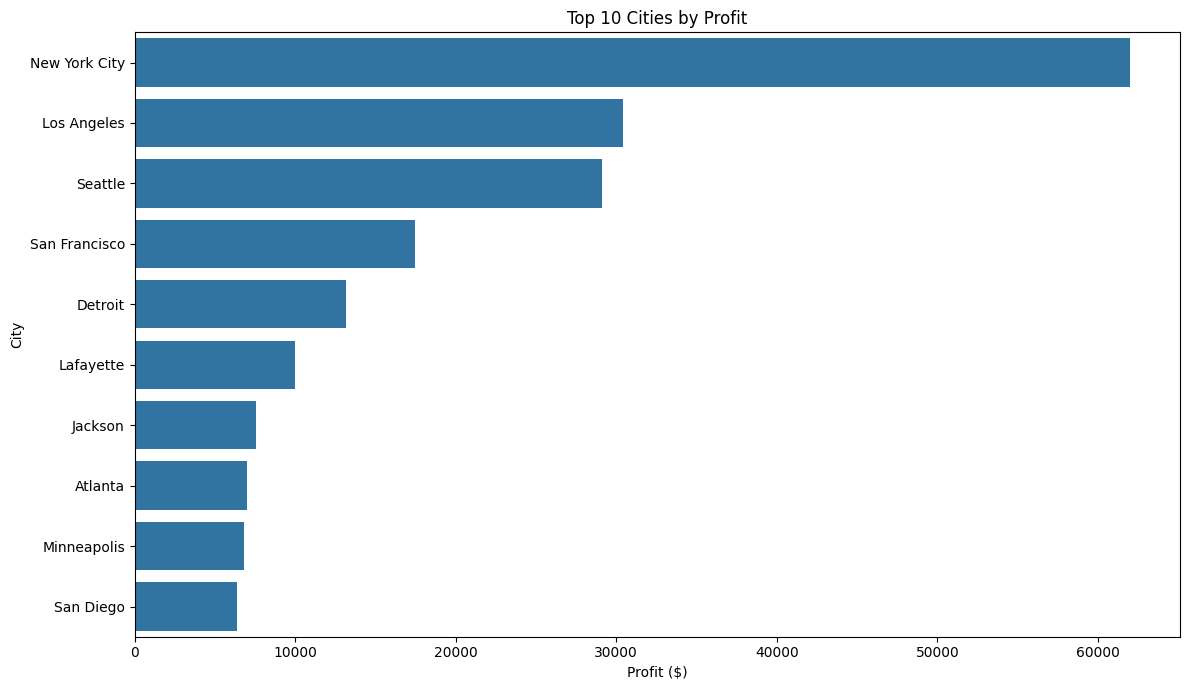

In [17]:
# ------------------------------------------------------------
# 18. TOP 10 CITIES BY PROFIT
# ------------------------------------------------------------

city_profit = df.groupby("City")["Profit"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=city_profit.values,
    y=city_profit.index
)

plt.title("Top 10 Cities by Profit")
plt.xlabel("Profit ($)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

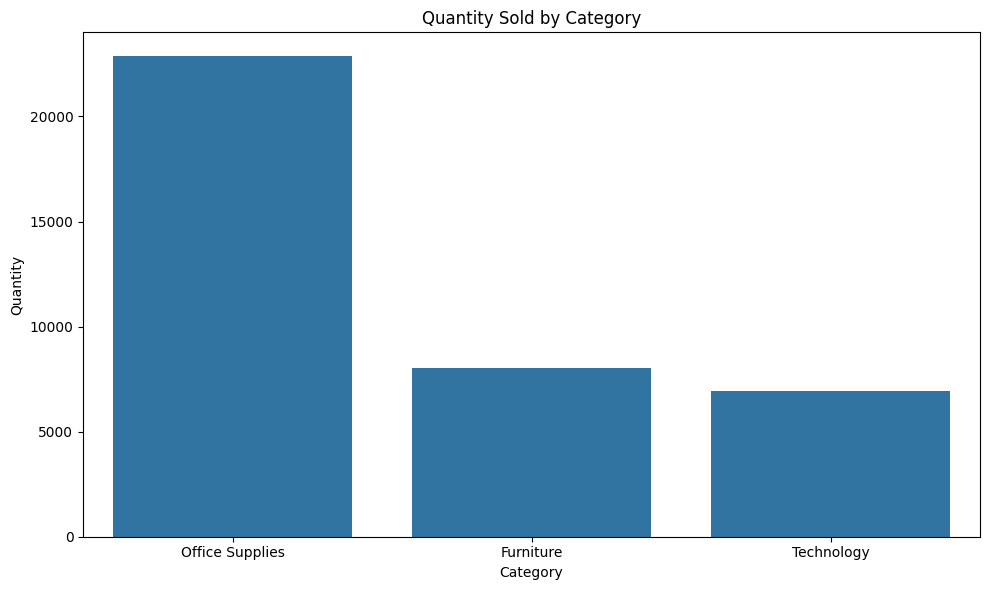

In [18]:
# ------------------------------------------------------------
# 19. QUANTITY BY CATEGORY
# ------------------------------------------------------------

category_quantity = df.groupby("Category")["Quantity"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_quantity.index,
    y=category_quantity.values
)

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()

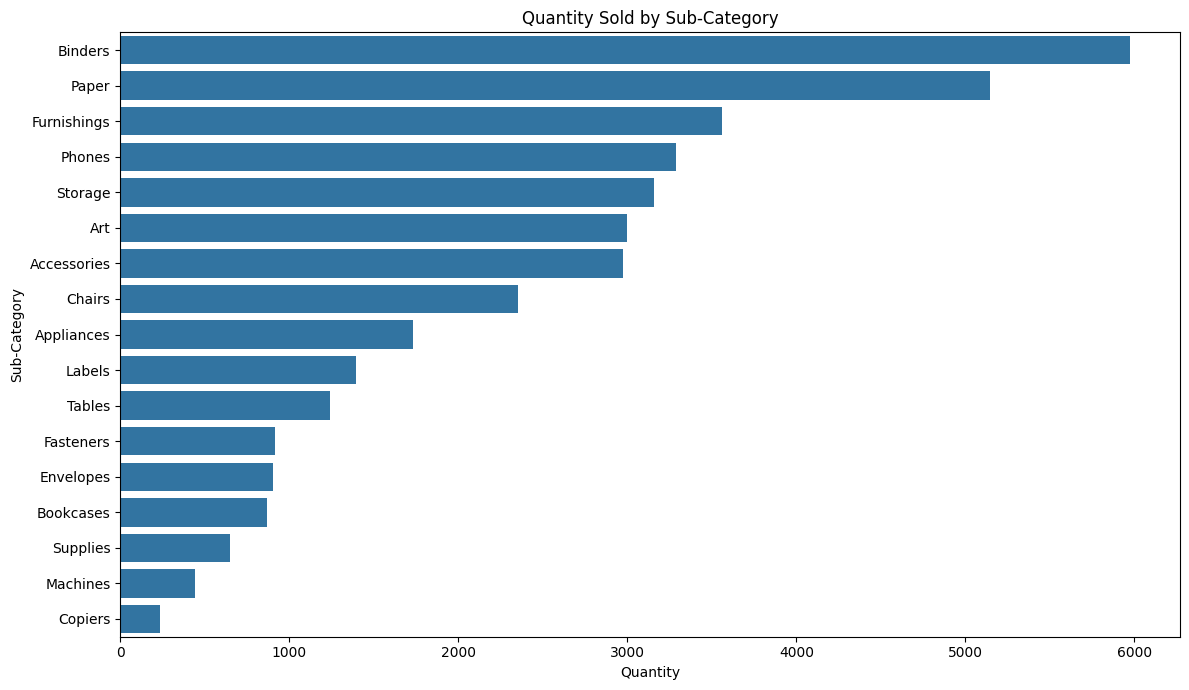

In [19]:
# ------------------------------------------------------------
# 20. QUANTITY BY SUB-CATEGORY
# ------------------------------------------------------------

subcategory_quantity = df.groupby("Sub-Category")["Quantity"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=subcategory_quantity.values,
    y=subcategory_quantity.index
)

plt.title("Quantity Sold by Sub-Category")
plt.xlabel("Quantity")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

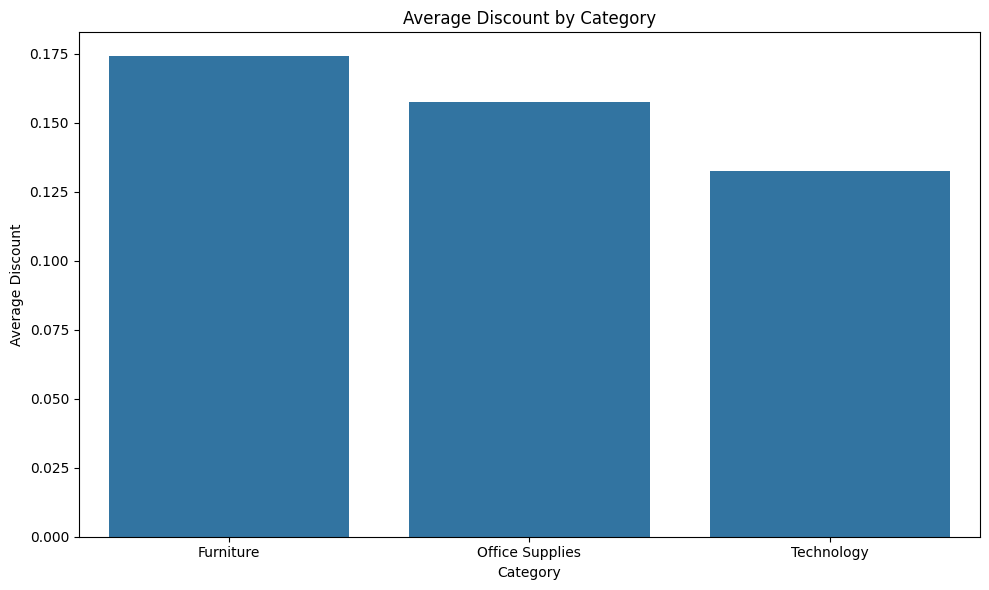

In [20]:
# ------------------------------------------------------------
# 21. AVERAGE DISCOUNT BY CATEGORY
# ------------------------------------------------------------

category_discount = df.groupby("Category")["Discount"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_discount.index,
    y=category_discount.values
)

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount")
plt.tight_layout()
plt.show()

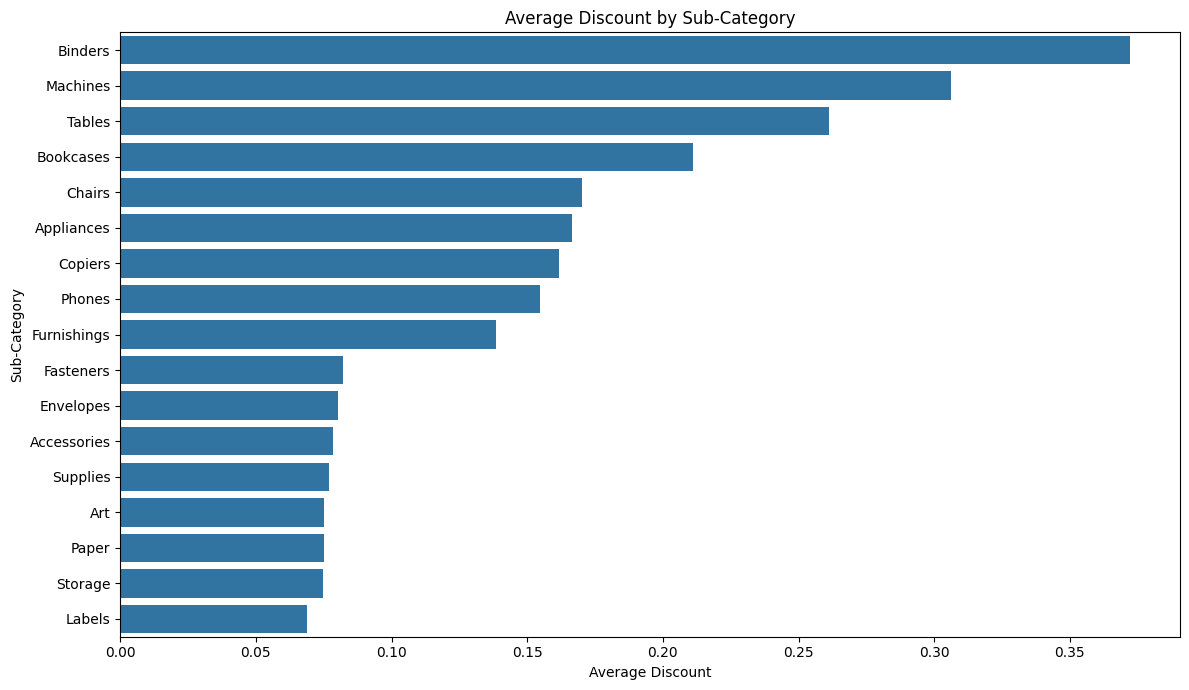

In [21]:
# ------------------------------------------------------------
# 22. AVERAGE DISCOUNT BY SUB-CATEGORY
# ------------------------------------------------------------

subcategory_discount = df.groupby("Sub-Category")["Discount"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=subcategory_discount.values,
    y=subcategory_discount.index
)

plt.title("Average Discount by Sub-Category")
plt.xlabel("Average Discount")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

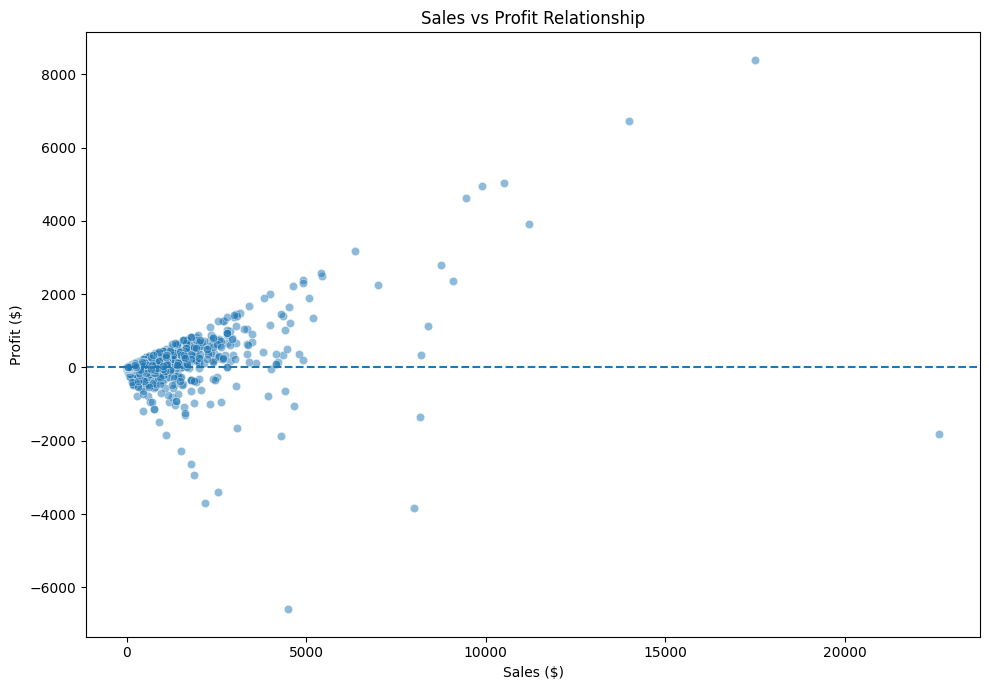

In [22]:
# ------------------------------------------------------------
# 23. SALES VS PROFIT
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.title("Sales vs Profit Relationship")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

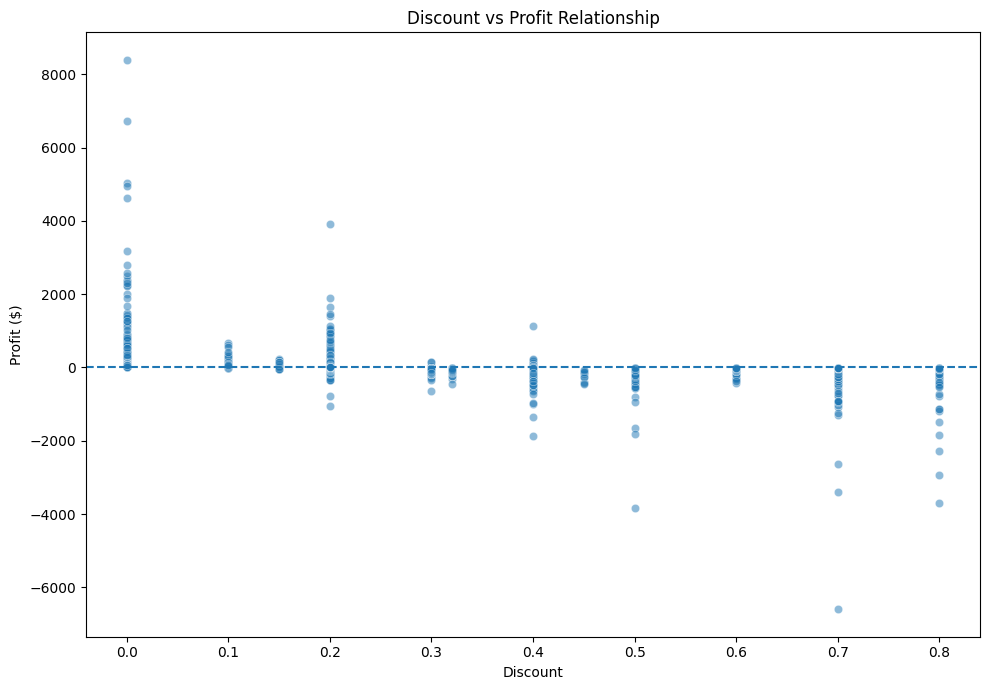

In [23]:
# ------------------------------------------------------------
# 24. DISCOUNT VS PROFIT
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.title("Discount vs Profit Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.tight_layout()
plt.show()

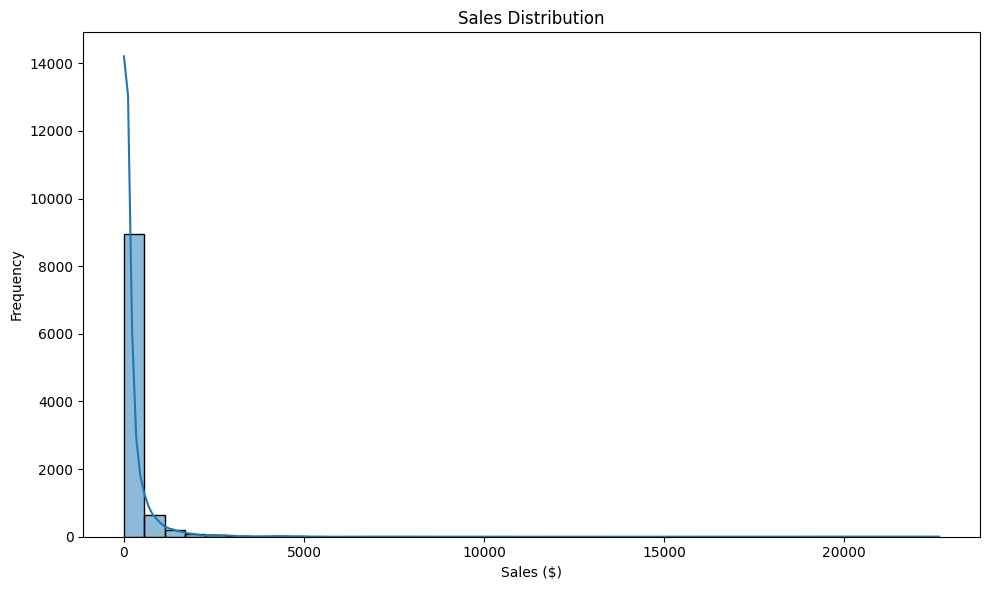

In [24]:
# ------------------------------------------------------------
# 25. SALES DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Sales"],
    bins=40,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

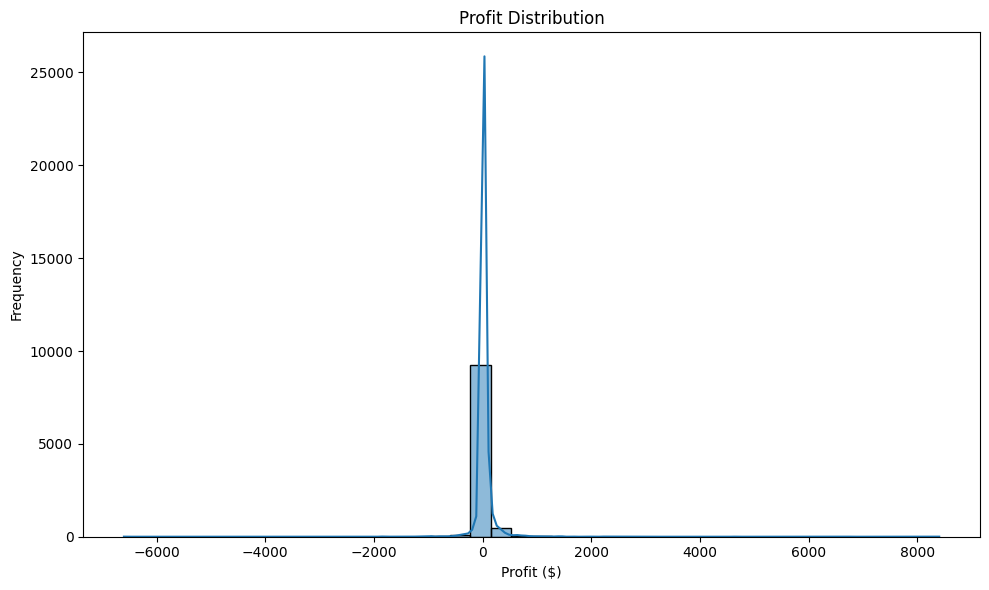

In [25]:
# ------------------------------------------------------------
# 26. PROFIT DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Profit"],
    bins=40,
    kde=True
)

plt.title("Profit Distribution")
plt.xlabel("Profit ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

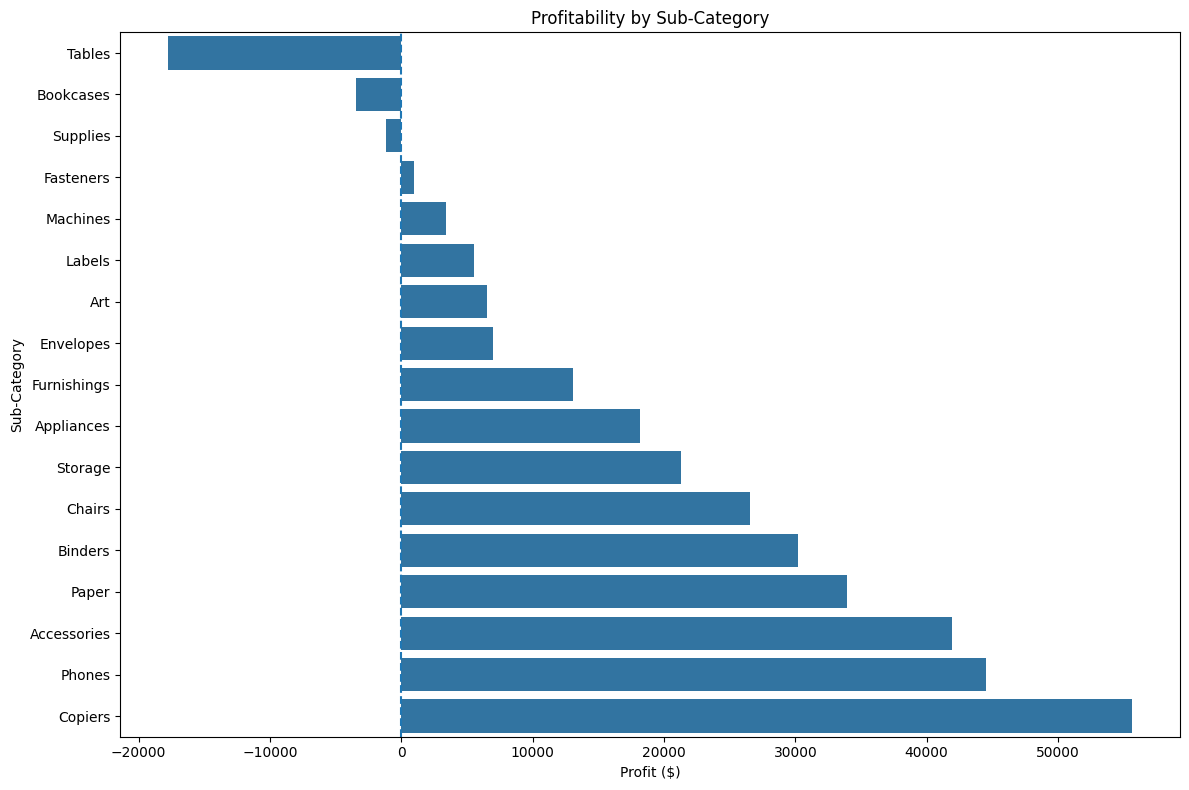

In [26]:
# ------------------------------------------------------------
# 29. PROFITABILITY BY SUB-CATEGORY
# ------------------------------------------------------------

profit_analysis = df.groupby("Sub-Category")["Profit"].sum().sort_values()

plt.figure(figsize=(12, 8))

sns.barplot(
    x=profit_analysis.values,
    y=profit_analysis.index
)

plt.axvline(0, linestyle="--")

plt.title("Profitability by Sub-Category")
plt.xlabel("Profit ($)")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

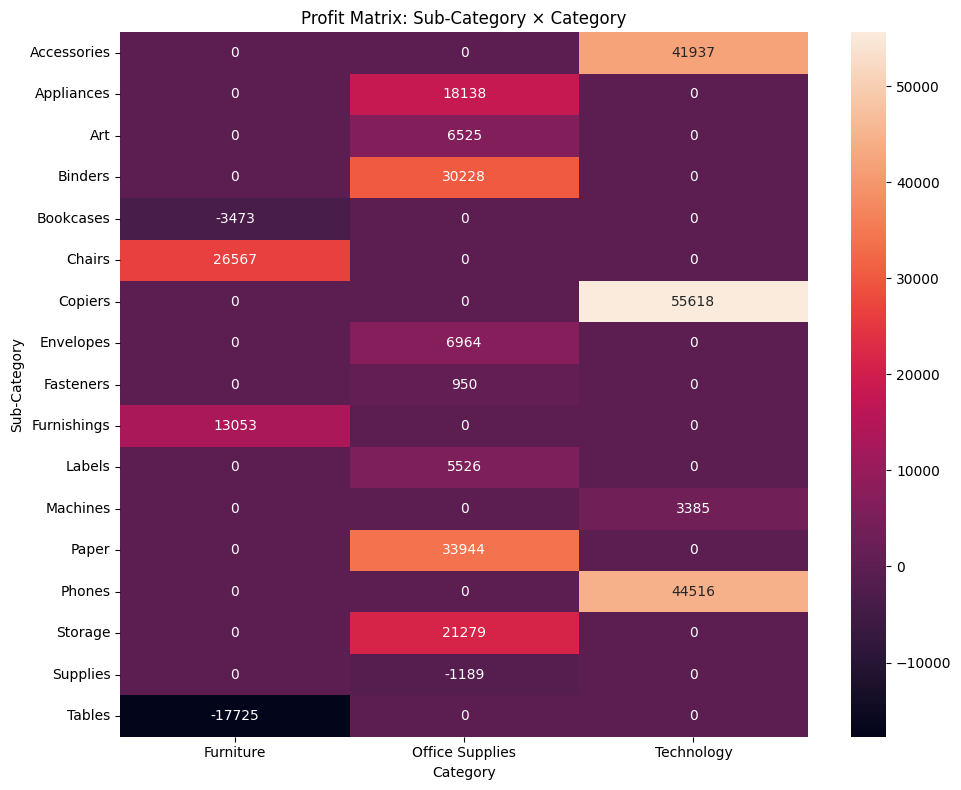

In [27]:
# ------------------------------------------------------------
# 30. PROFIT MATRIX
# ------------------------------------------------------------

profit_matrix = pd.pivot_table(
    df,
    index="Sub-Category",
    columns="Category",
    values="Profit",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    profit_matrix,
    annot=True,
    fmt=".0f"
)

plt.title("Profit Matrix: Sub-Category × Category")
plt.xlabel("Category")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

In [33]:
# ------------------------------------------------------------
# 31. MONTHLY SALES TREND
# ------------------------------------------------------------

# Check whether a date column exists

possible_date_columns = [
    "Order Date",
    "Order_Date",
    "Sales Date",
    "Sales_Date",
    "Date"
]

date_column = None

for col in possible_date_columns:
    if col in df.columns:
        date_column = col
        break

if date_column is not None:

    print("\nDate column found:", date_column)

    df[date_column] = pd.to_datetime(
        df[date_column],
        errors="coerce"
    )

    # Remove invalid dates
    df_date = df.dropna(subset=[date_column]).copy()

    # Create Month column
    df_date["Month"] = df_date[date_column].dt.to_period("M")

    monthly_sales = (
        df_date.groupby("Month")["Sales"]
        .sum()
        .reset_index()
    )

    monthly_sales["Month"] = monthly_sales["Month"].astype(str)

    print("\nMonthly Sales:")
    print(monthly_sales)

    # Monthly Sales Trend
    plt.figure(figsize=(14, 7))

    plt.plot(
        monthly_sales["Month"],
        monthly_sales["Sales"],
        marker="o"
    )

    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Sales ($)")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [34]:
# ------------------------------------------------------------
# 32. TOP 10 PROFITABLE SUB-CATEGORIES
# ------------------------------------------------------------

top_profit_subcategories = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Profitable Sub-Categories:")
print(top_profit_subcategories)


Top 10 Profitable Sub-Categories:
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          33944.2395
Binders        30228.0003
Chairs         26567.1278
Storage        21278.8264
Appliances     18138.0054
Furnishings    13052.7230
Envelopes       6964.1767
Name: Profit, dtype: float64


In [35]:
# ------------------------------------------------------------
# 33. TOP 10 LOSS-MAKING SUB-CATEGORIES
# ------------------------------------------------------------

loss_subcategories = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
    .head(10)
)

print("\nTop 10 Loss-Making Sub-Categories:")
print(loss_subcategories)


Top 10 Loss-Making Sub-Categories:
Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5526.3820
Art             6524.6118
Envelopes       6964.1767
Furnishings    13052.7230
Appliances     18138.0054
Name: Profit, dtype: float64


In [36]:
# ------------------------------------------------------------
# 34. SALES AND PROFIT SUMMARY
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Quantity",
        "Average Sales",
        "Average Profit",
        "Average Discount",
        "Profit Margin"
    ],
    "Value": [
        total_sales,
        total_profit,
        total_quantity,
        average_sales,
        average_profit,
        average_discount,
        profit_margin
    ]
})

print("\n================ FINAL SUMMARY ================")
print(summary)


================ FINAL SUMMARY ================
             Metric         Value
0       Total Sales  2.296196e+06
1      Total Profit  2.862414e+05
2    Total Quantity  3.782000e+04
3     Average Sales  2.301489e+02
4    Average Profit  2.869013e+01
5  Average Discount  1.562784e-01
6     Profit Margin  1.246590e+01


In [37]:
# ------------------------------------------------------------
# 35. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n================ CONCLUSION ================")

print(f"""
1. Total sales generated were ${total_sales:,.2f}.
2. Total profit generated was ${total_profit:,.2f}.
3. Overall profit margin was {profit_margin:.2f}%.
4. Category, sub-category, region and segment performance
   were analyzed using sales and profit.
5. State and city performance was analyzed using Top-10
   comparisons.
6. Quantity and discount patterns were also analyzed.
7. Sales vs Profit and Discount vs Profit relationships
   were visualized using scatter plots.
8. Distribution charts were created for Sales, Profit,
   Quantity and Discount.
9. Monthly Sales Trend requires a valid date column.
""")


================ CONCLUSION ================

1. Total sales generated were $2,296,195.59.
2. Total profit generated was $286,241.42.
3. Overall profit margin was 12.47%.
4. Category, sub-category, region and segment performance
   were analyzed using sales and profit.
5. State and city performance was analyzed using Top-10
   comparisons.
6. Quantity and discount patterns were also analyzed.
7. Sales vs Profit and Discount vs Profit relationships
   were visualized using scatter plots.
8. Distribution charts were created for Sales, Profit,
   Quantity and Discount.
9. Monthly Sales Trend requires a valid date column.

